In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load Data & Cleaning
path = r"../Projects/Housing_data.csv"
data = pd.read_csv(path)
data = data.drop("Id", axis=1)

# Log transform SalePrice to handle outliers
data["SalePrice"] = np.log1p(data["SalePrice"])

# Train/Test Split
X = data.drop("SalePrice", axis=1)
y = data["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Engineering & Imputation
# Function to process features to prevent data leakage.
def preprocess_features(X_data, is_train=True):

    df = X_data.copy()
    
    # categorical NAs with "None"
    none_cols = ["Alley", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
                 "FireplaceQu", "GarageType", "GarageFinish", "GarageQual", "GarageCond",
                 "PoolQC", "Fence", "MiscFeature", "MasVnrType"]
    df[none_cols] = df[none_cols].fillna("None")

    # zeros for numerical NAs
    zero_cols = ["MasVnrArea", "GarageYrBlt", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
                 "BsmtFullBath", "BsmtHalfBath", "GarageCars", "GarageArea"]
    df[zero_cols] = df[zero_cols].fillna(0)

    # LotFrontage by neighborhood median 
    df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(lambda x: x.fillna(x.median()))
    df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())

    # Fill Electrical with mode
    df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

    # custom features
    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
    df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]
    df["TotalBathrooms"] = df["FullBath"] + 0.5 * df["HalfBath"] + df["BsmtFullBath"] + 0.5 * df["BsmtHalfBath"]
    df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
    
    return df

# Applying to Train and Test separately!
X_train = preprocess_features(X_train)
X_test = preprocess_features(X_test)

# Encoding and Scaling
# Combining temporarily just for One-Hot Encoding so column names match exactly
X_train['is_train'] = 1
X_test['is_train'] = 0
combined = pd.concat([X_train, X_test])
combined = pd.get_dummies(combined, drop_first=True)

X_train = combined[combined['is_train'] == 1].drop('is_train', axis=1)
X_test = combined[combined['is_train'] == 0].drop('is_train', axis=1)

# Scaling the data for Ridge and Lasso
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# fitting the scaler on the training data
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [3]:
# 3. Baseline Evaluation

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.001, max_iter=40000),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingRegressor(max_iter=200, learning_rate=0.05, random_state=42)
}

print("--- Baseline Evaluation ---")
results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results.append({"Model": name, "RMSE": rmse, "R2": r2})

baseline_results = pd.DataFrame(results).sort_values(by="RMSE")
display(baseline_results)

--- Baseline Evaluation ---


,Model,RMSE,R2
4,HistGradientBoosting,0.145967,0.866633
3,Random Forest,0.168354,0.822588
2,Lasso Regression,0.241564,0.634740
1,Ridge Regression,0.293289,0.461573
0,Linear Regression,0.342065,0.267592


In [4]:
# 4. Hyperparameter Tuning (simplified & parallelized)

ridge_params = {'alpha': [0.01, 0.1, 1, 10, 50]}
lasso_params = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1]}
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
hgb_params = {
    'max_iter': [100, 200],
    'max_depth': [None, 10],
    'learning_rate': [0.01, 0.05, 0.1]
}

# Initialise models
ridge = Ridge()
lasso = Lasso(max_iter=40000)
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
hgb = HistGradientBoostingRegressor(random_state=42)

# Grid / Randomized Search
ridge_grid = GridSearchCV(ridge, ridge_params, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
lasso_grid = GridSearchCV(lasso, lasso_params, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
rf_grid = RandomizedSearchCV(rf, rf_params, n_iter=5, cv=3, scoring='neg_root_mean_squared_error', random_state=42, n_jobs=-1)
hgb_grid = RandomizedSearchCV(hgb, hgb_params, n_iter=5, cv=3, scoring='neg_root_mean_squared_error', random_state=42, n_jobs=-1)

# Fit tuned models
ridge_grid.fit(X_train_scaled, y_train)
lasso_grid.fit(X_train_scaled, y_train)
rf_grid.fit(X_train_scaled, y_train)
hgb_grid.fit(X_train_scaled, y_train)

print("--- Best Parameters Found ---")
print("Ridge:", ridge_grid.best_params_)
print("Lasso:", lasso_grid.best_params_)
print("Random Forest:", rf_grid.best_params_)
print("HistGradientBoosting:", hgb_grid.best_params_)

--- Best Parameters Found ---
Ridge: {'alpha': 50}
Lasso: {'alpha': 0.01}
Random Forest: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10}
HistGradientBoosting: {'max_iter': 100, 'max_depth': 10, 'learning_rate': 0.1}


In [5]:
# 5. Final Evaluation

best_models = {
    "Ridge": ridge_grid.best_estimator_,
    "Lasso": lasso_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_,
    "HistGradientBoosting": hgb_grid.best_estimator_
}

eval_results = []
for name, model in best_models.items():
    preds = model.predict(X_test_scaled)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
    eval_results.append({"Model": name, "MSE": mse, "RMSE": rmse, "R2": r2})

results_df = pd.DataFrame(eval_results).sort_values(by="RMSE")
print("\n--- Final Tuned Model Evaluation ---")
display(results_df)


--- Final Tuned Model Evaluation ---


,Model,MSE,RMSE,R2
3,HistGradientBoosting,0.020898,0.144562,0.869188
0,Ridge,0.025435,0.159485,0.840788
1,Lasso,0.026085,0.161509,0.836721
2,Random Forest,0.028304,0.168238,0.822832


In [6]:
# The Best Model
best_model_name = results_df.iloc[0]['Model']
best_model = best_models[best_model_name]
print(f"The Best Model is: {best_model_name}")

The Best Model is: HistGradientBoosting


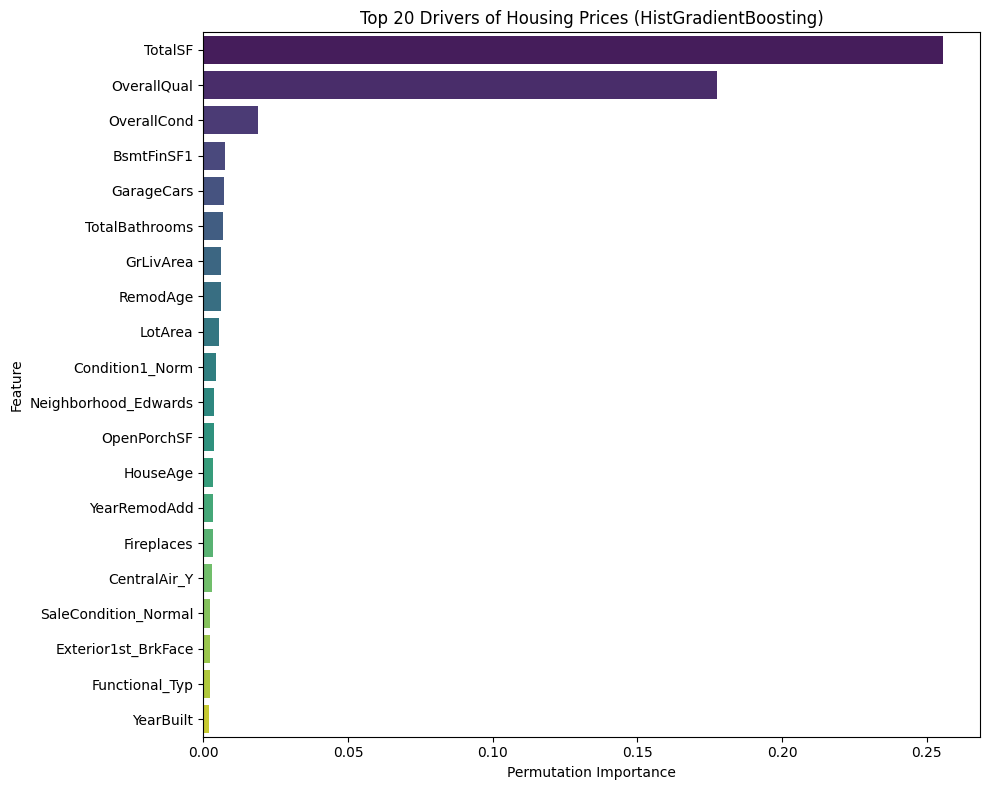

In [7]:
# 6. Feature Importances (for tree-based models)
result = permutation_importance(best_model, X_test_scaled, y_test, n_repeats=10, random_state=42, n_jobs=-1)

feature_importances = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Importance": result.importances_mean
}).sort_values(by="Importance", ascending=False)

# Plot Top 20
plt.figure(figsize=(10,8))
sns.barplot(data=feature_importances.head(20), x='Importance', y='Feature',hue='Feature', palette='viridis', legend=False)
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title(f"Top 20 Drivers of Housing Prices ({best_model_name})")
plt.tight_layout()
plt.show()